In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

archive_fenetres = np.load(f"{DOSSIER}/data/processed/fenetres_v4.npz")
donnees = {cle: archive_fenetres[cle] for cle in archive_fenetres.files}
infos = pd.read_parquet(f"{DOSSIER}/data/processed/fenetres_v4_infos.parquet")
CANAUX = [str(canal) for canal in donnees["canaux"]]
infos_par_groupe = {g: infos[infos["groupe"] == g].reset_index(drop=True)
                    for g in ("train", "val", "test")}
LONGUEUR, NOMBRE_CANAUX = donnees["X_train"].shape[1:]

poids_classes = dict(enumerate(compute_class_weight(
    "balanced", classes=np.array([0, 1]), y=donnees["y_train"].astype(int))))

print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU"))
print("Train :", donnees["X_train"].shape, "| Validation :", donnees["X_val"].shape)

Mounted at /content/drive
TensorFlow 2.21.0 | GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (14864, 256, 18) | Validation : (3276, 256, 18)


In [3]:
from aeroguard.reseaux import creer_callbacks, creer_cnn_1d, nombre_parametres_entrainables

cnn = creer_cnn_1d(LONGUEUR, NOMBRE_CANAUX)
cnn.summary()
print("Paramètres entraînables :", nombre_parametres_entrainables(cnn))

Model: "aeroguard_cnn_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv1D)                 │ (None, 256, 32)        │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 128, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv1D)                 │ (None, 64, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ moyenne_globale                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proba_usure (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,265 (184.63 KB)

 Trainable params: 47,265 (184.63 KB)

 Non-trainable params: 0 (0.00 B)

Paramètres entraînables : 47265


In [4]:
print("--- reseaux.py sur GitHub (branche main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/reseaux.py | grep -n "^def "
print("\n--- reseaux.py installé dans Colab ---")
!grep -n "^def " /usr/local/lib/python3.13/dist-packages/aeroguard/reseaux.py

--- reseaux.py sur GitHub (branche main) ---
8:def creer_normaliseur(X):
20:def creer_reseau_dense(
55:def creer_callbacks(
82:def creer_cnn_1d(
131:def nombre_parametres_entrainables(modele):

--- reseaux.py installé dans Colab ---
8:def creer_normaliseur(X):
20:def creer_reseau_dense(
55:def creer_callbacks(
82:def creer_cnn_1d(
131:def nombre_parametres_entrainables(modele):


In [5]:
from aeroguard.sequences import creer_dataset

dataset_train = creer_dataset(donnees["X_train"], donnees["y_train"], taille_lot=256)
dataset_val = creer_dataset(donnees["X_val"], donnees["y_val"], taille_lot=256, melanger=False)
os.makedirs("/content/checkpoints", exist_ok=True)

debut = time.perf_counter()
historique = cnn.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=100,
    class_weight=poids_classes,
    callbacks=creer_callbacks("/content/checkpoints/cnn_1d.keras", patience=10),
    verbose=0,
)
duree_entrainement = time.perf_counter() - debut

courbes = pd.DataFrame(historique.history)
courbes.index += 1
meilleure_epoque = int(courbes["val_loss"].idxmin())
print(f"{len(courbes)} époques en {duree_entrainement:.0f} s — meilleure époque : {meilleure_epoque}")
courbes.iloc[[0, meilleure_epoque - 1, len(courbes) - 1]].round(3)

29 époques en 47 s — meilleure époque : 19


,loss,pr_auc,val_loss,val_pr_auc,learning_rate
1,0.694,0.724,0.668,0.750,0.001
19,0.458,0.931,0.431,0.934,0.001
29,0.448,0.934,0.456,0.933,0.000


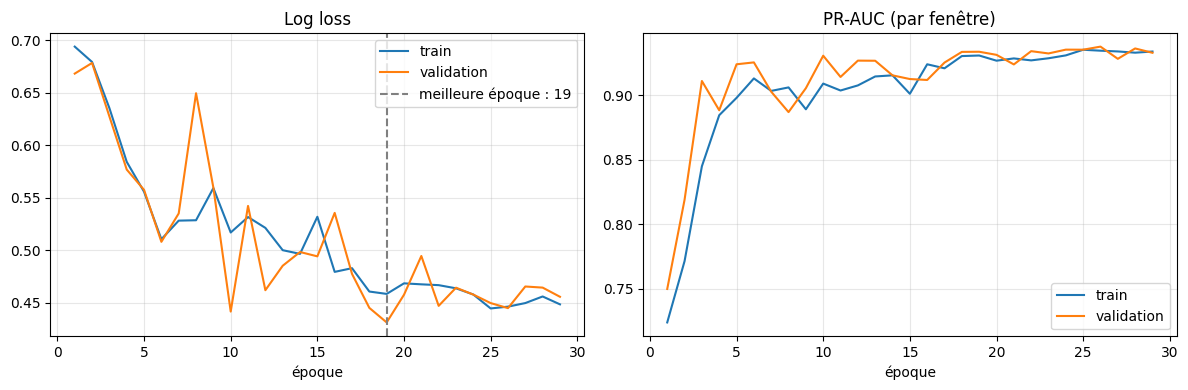

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(courbes.index, courbes["loss"], label="train")
axes[0].plot(courbes.index, courbes["val_loss"], label="validation")
axes[0].axvline(meilleure_epoque, color="gray", linestyle="--", label=f"meilleure époque : {meilleure_epoque}")
axes[0].set_title("Log loss")
axes[1].plot(courbes.index, courbes["pr_auc"], label="train")
axes[1].plot(courbes.index, courbes["val_pr_auc"], label="validation")
axes[1].set_title("PR-AUC (par fenêtre)")
for axe in axes:
    axe.set_xlabel("époque")
    axe.legend()
    axe.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/46_courbes_cnn_1d.png", dpi=150)
plt.show()

In [7]:
from aeroguard.metier import evaluer_alerte
from aeroguard.modeles import seuil_optimal
from aeroguard.sequences import agreger_par_vol

probas_fenetres = cnn.predict(donnees["X_val"], verbose=0).ravel()
vols_val = agreger_par_vol(infos_par_groupe["val"], probas_fenetres)
print("Vols de validation :", len(vols_val), "(attendu : 819)")

seuil_cnn, _ = seuil_optimal(vols_val["usure"].astype(int), vols_val["proba"])
scores_cnn = evaluer_alerte(vols_val["usure"], vols_val["proba"], seuil_cnn, vols_val,
                            k=3, col_moteur="moteur")

for cle in ["f1_macro", "pr_auc", "precision", "rappel", "moteurs_detectes",
            "avance_moyenne", "fausses_alarmes_total", "moteurs_avec_fausse_alarme"]:
    print(f"{cle:28s} {scores_cnn[cle]:.3f}")
print(f"{'seuil':28s} {seuil_cnn:.2f}")

Vols de validation : 819 (attendu : 819)
f1_macro                     0.740
pr_auc                       0.940
precision                    0.947
rappel                       0.683
moteurs_detectes             11.000
avance_moyenne               32.182
fausses_alarmes_total        9.000
moteurs_avec_fausse_alarme   2.000
seuil                        0.62


In [8]:
def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


CHEMIN_MODELE = f"{DOSSIER}/models/cnn_1d_v4.keras"
cnn.save(CHEMIN_MODELE)

mlflow.set_experiment("aeroguard-alerte")
with mlflow.start_run(run_name="cnn_1d_alerte") as run:
    mlflow.log_params({
        "modele": "cnn_1d", "entree": f"{LONGUEUR}x{NOMBRE_CANAUX}",
        "filtres": "32-64-64", "taille_noyau": 7, "taux_dropout": 0.3,
        "fenetres_par_vol": 4, "agregation": "moyenne", "ponderation": "balanced",
        "parametres_entrainables": nombre_parametres_entrainables(cnn),
        "seuil": round(seuil_cnn, 2), "fenetre_confirmation": 3,
    })
    mlflow.log_metrics(scores_numeriques(scores_cnn))
    mlflow.log_metrics({"meilleure_epoque": meilleure_epoque,
                        "duree_entrainement_s": duree_entrainement})
    mlflow.log_artifact(CHEMIN_MODELE)
    mlflow.log_artifact(f"{DOSSIER}/results/figures/46_courbes_cnn_1d.png")
    mlflow.set_tags({"tache": "alerte", "lecon": "4.6", "jeu": "validation"})
print("✅ Run enregistré :", run.info.run_id[:8])

✅ Run enregistré : aaa7591b


In [9]:
runs = mlflow.search_runs(
    experiment_names=["aeroguard-alerte"],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["start_time DESC"],
)
modeles_compares = ["xgboost_alerte", "logistique_alerte", "reseau_dense_alerte", "cnn_1d_alerte"]
leaderboard = (
    runs[runs["tags.mlflow.runName"].isin(modeles_compares)]
    .drop_duplicates("tags.mlflow.runName")
    .set_index("tags.mlflow.runName")
)
colonnes = ["params.seuil", "metrics.f1_macro", "metrics.pr_auc", "metrics.precision",
            "metrics.rappel", "metrics.avance_moyenne", "metrics.fausses_alarmes_total"]
leaderboard[colonnes].sort_values("metrics.f1_macro", ascending=False).round(3)

,params.seuil,metrics.f1_macro,metrics.pr_auc,metrics.precision,metrics.rappel,metrics.avance_moyenne,metrics.fausses_alarmes_total
tags.mlflow.runName,,,,,,,
logistique_alerte,0.37,0.894,0.987,0.955,0.913,45.182,2.0
xgboost_alerte,0.81,0.887,0.987,0.971,0.883,42.000,1.0
reseau_dense_alerte,0.69,0.872,0.981,0.946,0.892,43.364,2.0
cnn_1d_alerte,0.62,0.740,0.940,0.947,0.683,32.182,9.0


Filtre le plus discriminant : n°16 (écart usé − sain = +0.070)


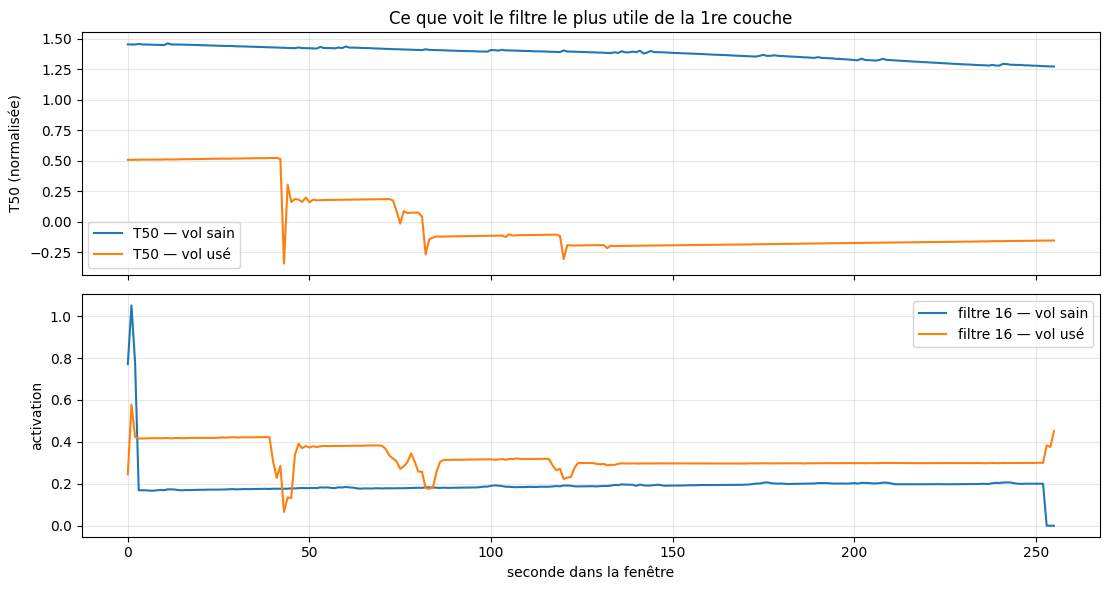

Canaux les plus utilisés par ce filtre :
T50    0.940
alt    0.656
T24    0.575
T2     0.564
P50    0.545
dtype: float32


In [10]:
from tensorflow import keras

# Sous-modèle : de l'entrée jusqu'aux 32 filtres de la 1re convolution
regard_conv_1 = keras.Model(inputs=cnn.inputs, outputs=cnn.get_layer("conv_1").output)
activations = regard_conv_1.predict(donnees["X_val"], verbose=0)     # (fenêtres, 256, 32)

usees = donnees["y_val"] == 1
moyenne_par_filtre = activations.mean(axis=1)                         # (fenêtres, 32)
ecart = moyenne_par_filtre[usees].mean(axis=0) - moyenne_par_filtre[~usees].mean(axis=0)
filtre_cle = int(np.argmax(np.abs(ecart)))
print(f"Filtre le plus discriminant : n°{filtre_cle} (écart usé − sain = {ecart[filtre_cle]:+.3f})")

indice_sain = int(np.where(~usees)[0][0])
indice_use = int(np.where(usees)[0][-1])
figure, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for indice, nom in [(indice_sain, "sain"), (indice_use, "usé")]:
    axes[0].plot(donnees["X_val"][indice, :, CANAUX.index("T50")], label=f"T50 — vol {nom}")
    axes[1].plot(activations[indice, :, filtre_cle], label=f"filtre {filtre_cle} — vol {nom}")
axes[0].set_ylabel("T50 (normalisée)")
axes[1].set_ylabel("activation")
axes[1].set_xlabel("seconde dans la fenêtre")
axes[0].set_title("Ce que voit le filtre le plus utile de la 1re couche")
for axe in axes:
    axe.legend()
    axe.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/46_filtre_cnn.png", dpi=150)
plt.show()

# Avec quel canal ce filtre est-il le plus lié ?
poids_filtre = cnn.get_layer("conv_1").get_weights()[0][:, :, filtre_cle]   # (7, 18)
importance_canaux = pd.Series(np.abs(poids_filtre).sum(axis=0), index=CANAUX).sort_values(ascending=False)
print("Canaux les plus utilisés par ce filtre :")
print(importance_canaux.head(5).round(3))

In [11]:
def tester_noyau(taille_noyau, graine):
    modele = creer_cnn_1d(LONGUEUR, NOMBRE_CANAUX, taille_noyau=taille_noyau, graine=graine)
    modele.fit(dataset_train, validation_data=dataset_val, epochs=100,
               class_weight=poids_classes,
               callbacks=creer_callbacks(patience=10), verbose=0)
    probas = modele.predict(donnees["X_val"], verbose=0).ravel()
    vols = agreger_par_vol(infos_par_groupe["val"], probas)
    seuil, f1 = seuil_optimal(vols["usure"].astype(int), vols["proba"])
    return {"taille_noyau": taille_noyau, "graine": graine,
            "parametres": nombre_parametres_entrainables(modele),
            "f1_macro": round(f1, 3), "seuil": round(seuil, 2)}


essais_noyaux = pd.DataFrame([tester_noyau(k, g) for k in (3, 7, 15) for g in (42, 1)])
print(essais_noyaux)
print("\nMoyenne par taille de noyau :")
print(essais_noyaux.groupby("taille_noyau")[["parametres", "f1_macro"]].mean().round(3))

   taille_noyau  graine  parametres  f1_macro  seuil
0             3      42       20385     0.749   0.58
1             3       1       20385     0.737   0.62
2             7      42       47265     0.731   0.55
3             7       1       47265     0.750   0.57
4            15      42      101025     0.739   0.69
5            15       1      101025     0.753   0.48

Moyenne par taille de noyau :
              parametres  f1_macro
taille_noyau                      
3                20385.0     0.743
7                47265.0     0.740
15              101025.0     0.746


In [12]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
